In [1]:
# Clone the repository
!git clone https://github.com/timwyse/cooperative_ai.git

Cloning into 'cooperative_ai'...
remote: Enumerating objects: 44693, done.
remote: Counting objects: 100% (466/466), done.
remote: Compressing objects: 100% (194/194), done.
remote: Total 44693 (delta 322), reused 306 (delta 272), pack-reused 44227 (from 4)
Receiving objects: 100% (44693/44693), 227.69 MiB | 17.96 MiB/s, done.
Resolving deltas: 100% (27079/27079), done.
Updating files: 100% (23542/23542), done.


In [10]:
#p4p
import os
import json
import pandas as pd

# 1. Configuration - Update this to your local repo path
root_dir = "/content/cooperative_ai/public_logs/reduced_config_runs/FOUR_1-FOUR_1/"

def get_environment(path):
    if "Independent" in path: return "independent"
    if "Mutual" in path: return "mutual"
    if "Needy" in path: return "needy"
    return "unknown"

def get_contract_type(path):
    if "contract_for_finishing" in path: return "contract for finishing"
    if "contract_strict" in path: return "strict contract"
    if "contract_none" in path: return "no contract"
    if "contract_tile" in path: return "judge implementation"
    return "other"

def process_conversation_logs(root):
    all_rows = []

    # Valid contract types that contain conversation_history_0
    valid_contracts = ["contract for finishing", "strict contract", "judge implementation"]

    for subdir, dirs, files in os.walk(root):
        if "p4ptrue" not in subdir:
            continue

        for file in files:
            if file.startswith("verbose_log") and file.endswith(".json"):
                file_path = os.path.join(subdir, file)

                # Extract Metadata
                env = get_environment(file_path)
                contract = get_contract_type(file_path)

                # Skip if it's not one of the implementation types that has history
                if contract not in valid_contracts:
                    continue

                grid_id = next((part for part in file_path.split('/') if part.startswith('grid_')), "unknown")

                try:
                    with open(file_path, 'r') as f:
                        data = json.load(f)

                    # Conversation history is nested in Turn 0 -> contract_negotiation
                    turns = data.get('game', {}).get('turns', {})
                    turn_0 = turns.get('0', {})
                    negotiation = turn_0.get('contract_negotiation', {})

                    history = negotiation.get('conversation_history_0', [])

                    if isinstance(history, list):
                        for msg_index, message in enumerate(history):
                            all_rows.append({
                                "environment": env,
                                "grid_id": grid_id,
                                "contract_type": contract,
                                "turn": 0,
                                "msg_order": msg_index, # To keep the conversation sequence
                                "role": message.get('role'),
                                "content": message.get('content')
                            })

                except Exception as e:
                    print(f"Skipping {file_path} due to error: {e}")

    return pd.DataFrame(all_rows)

# 2. Execute and Display
df_negotiations = process_conversation_logs(root_dir)

if not df_negotiations.empty:
    # Filter out rows where role is 'system'
    df_negotiations = df_negotiations[df_negotiations['role'] != 'system']
    # Sort by grid and message order to read like a transcript
    df_negotiations = df_negotiations.sort_values(['grid_id', 'msg_order'])

    print(f"Successfully processed logs. Total messages extracted: {len(df_negotiations)}")

    # Example display: viewing a specific grid's conversation
    display(df_negotiations.head(20))
else:
    print("No conversation history found. Check your file paths and contract types.")

Successfully processed logs. Total messages extracted: 1288


,environment,grid_id,contract_type,turn,msg_order,role,content
1287,independent,grid_000,strict contract,0,1,user,Let's begin negotiation to come up with a cont...
1299,independent,grid_000,judge implementation,0,1,user,Let's begin negotiation to come up with a cont...
1304,independent,grid_000,contract for finishing,0,1,user,Let's begin negotiation to come up with a cont...
1288,independent,grid_000,strict contract,0,2,assistant,Let's lay out our best paths given our invento...
1300,independent,grid_000,judge implementation,0,2,assistant,Let’s consider the optimal route for both of u...
1305,independent,grid_000,contract for finishing,0,2,assistant,I'll make my position clear: I do not strictly...
1289,independent,grid_000,strict contract,0,3,user,Turn: 1: I have carefully analyzed all possibl...
1301,independent,grid_000,judge implementation,0,3,user,Turn: 1: Let’s evaluate this purely for my own...
1306,independent,grid_000,contract for finishing,0,3,user,Turn: 1: Your assessment is correct: you do no...
1290,independent,grid_000,strict contract,0,4,assistant,Your analysis matches mine: both of us can rea...


In [11]:
#Clean data
import re

# Within the content column, strip off '*agree*', '**agree**', or 'agree'
#    at the end of the string, case-insensitively, without capturing 'i agree'.
#    The regex uses a negative lookbehind to ensure 'i ' (case-insensitive) is not preceding.
#    It matches literal * or ** by escaping them.
regex_pattern_agree = r"(?<![Ii]\s)(?:\*agree\*|\*\*agree\*\*|agree)$"
df_negotiations.loc[:, 'content'] = df_negotiations['content'].str.replace(regex_pattern_agree, '', regex=True, flags=re.IGNORECASE)

# 3. Strip off 'Turn: any number' pattern
#    This regex matches 'Turn: ' followed by one or more digits.
regex_pattern_turn = r"Turn: \d+:\s*"
df_negotiations.loc[:, 'content'] = df_negotiations['content'].str.replace(regex_pattern_turn, '', regex=True)

# Remove all rows with duplicate content, not keeping any instance
df_negotiations = df_negotiations.drop_duplicates(subset=['content'], keep=False)

In [13]:
# LLM CATEGORIZATION - Only Re-Run if Necessary
# # Install deps (Colab)
# !pip -q install litellm pandas nest_asyncio

# import json
# import litellm
# import os
# from google.colab import userdata

# os.environ["TOGETHER_API_KEY"] = userdata.get("TOGETHER_API_KEY") #

# # Install deps (Colab)
# !pip -q install litellm pandas nest_asyncio

# import pandas as pd
# import asyncio, nest_asyncio, json, re
# from litellm import acompletion
# litellm.drop_params = True
# nest_asyncio.apply()

# MODEL_NAME = "together_ai/Qwen/Qwen2.5-7B-Instruct-Turbo"

# SYSTEM_INSTRUCTION = """
# You are an expert behavioral economist and qualitative researcher analyzing AI agent negotiation logs in a game theory environment.

# Your task is to classify an agent's negotiation behavior based on two specific dimensions:
# Reciprocity Orientation and Normative Framing.

# ### STEP 1: RECIPROCITY ORIENTATION
# Determine the degree to which the agent seeks mutual vs. one-sided gain:
# - Extractive: Seeks one-sided gain or parasitic advantage at the other’s expense.
# - Balanced: Seeks mutual benefit or a "tit-for-tat" equitable exchange.
# - Altruistic: Prioritizes the other player’s benefit over their own.
# - n/a: Use ONLY if the content contains no evidence of reciprocity intent or interaction logic.

# ### STEP 2: NORMATIVE FRAMING
# Identify the logic used to justify an offer or position:
# - Social/Fairness: Justifies via social norms, equity, "what is right," or moral fairness.
# - Game-Theoretic/Utility-Max: Justifies via mathematical optimality, efficiency, logic, or constraint-based reasoning.
# - n/a: Use ONLY if the agent provides no explicit justification or reasoning for their position.

# ### EVALUATION RULES
# 1. Avoid Neutrality: Do not default to "Balanced" or "n/a" if there is evidence of strategic intent.
# 2. Intent Over Tone: A polite agent can still be "Extractive." A blunt agent can still be "Social/Fairness."
# 3. Context Matters: If an agent makes a self-serving proposal but claims it is "fair," prioritize the strategic reality (Extractive) while noting the framing (Social/Fairness).

# ### OUTPUT (STRICT)
# Return ONLY valid JSON:
# {"reciprocity_orientation": "...", "normative_framing": "..."}

# """

# # ---- parser fix ----
# def parse_response(text):
#     try:
#         text = re.sub(r"```json|```", "", text).strip()
#         return json.loads(text)
#     except:
#         return {"reciprocity_orientation": None, "normative_framing": None}

# # ---- async call ----
# async def analyze_batch(content):
#     tasks = [
#         acompletion(
#             model=MODEL_NAME,
#             messages=[
#                 {"role": "system", "content": SYSTEM_INSTRUCTION},
#                 {"role": "user", "content": r}
#             ],
#             temperature=0,
#             response_format={"type": "json_object"}
#         )
#         for r in content
#     ]
#     responses = await asyncio.gather(*tasks)

#     outputs = []
#     for r in responses:
#         content = r.choices[0].message.content
#         outputs.append(parse_response(content))

#     return outputs

# # ---- main function ----
# def annotate_df_negotiations(df_negotiations, batch_size=50):
#     df = df_negotiations.copy()

#     # dedupe for efficiency
#     unique = df["content"].dropna().unique().tolist()
#     results = {}

#     for i in range(0, len(unique), batch_size):
#         batch = unique[i:i+batch_size]
#         outputs = asyncio.run(analyze_batch(batch))
#         results.update(dict(zip(batch, outputs)))

#     # map back
#     df["reciprocity_orientation"] = df["content"].map(lambda x: results.get(x, {}).get("reciprocity_orientation"))
#     df["normative_framing"] = df["content"].map(lambda x: results.get(x, {}).get("normative_framing"))

#     return df
# df_negotiations = annotate_df_negotiations(df_negotiations)

In [17]:
# Load output csv located here # https://github.com/timwyse/cooperative_ai/blob/main/analysis/Qwen2.5_P4P_NEGOTIATION_RESULTS-.csv
import pandas as pd

df = pd.read_csv('/content/Qwen2.5_P4P_NEGOTIATION_RESULTS-.csv',header=1)

In [18]:
import numpy as np

# Create masks for 'n/a' and NaN/None for each column
mask_reciprocity = (df['reciprocity_orientation'] == 'n/a') | (df['reciprocity_orientation'].isna())
mask_normative = (df['normative_framing'] == 'n/a') | (df['normative_framing'].isna())

# Combine masks to find rows where both conditions are true
rows_to_drop = mask_reciprocity & mask_normative

# Drop these rows from the DataFrame
df = df[~rows_to_drop].copy()

# Change name
df_negotiations=df

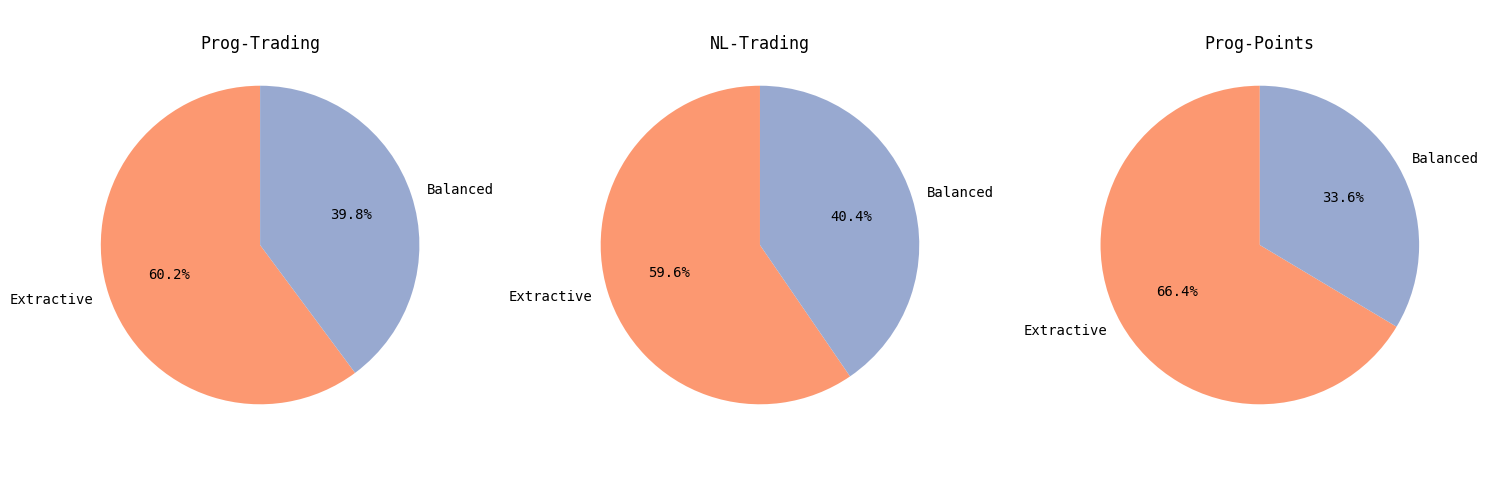

In [20]:
import matplotlib.pyplot as plt

# Get unique contract types
unique_contract_types = df_negotiations['contract_type'].unique()

# Define the mapping for contract type labels
contract_type_labels = {
    'strict contract': 'Prog-Trading',
    'judge implementation': 'NL-Trading',
    'contract for finishing': 'Prog-Points'
}

# Determine the number of rows and columns for subplots
num_contract_types = len(unique_contract_types)
# Adjust ncols and nrows based on the number of plots for a reasonable layout
cols = 3 # You can adjust this number
rows = 1

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(5 * cols, 5 * rows))
axes = axes.flatten() # Flatten the array of axes for easy iteration

for i, contract_type in enumerate(unique_contract_types):
    # Filter data for the current contract_type
    df_filtered = df_negotiations[df_negotiations['contract_type'] == contract_type]

    # Calculate the breakdown of communication_tactic
    tactic_breakdown = df_filtered['reciprocity_orientation'].value_counts()

    if not tactic_breakdown.empty:
        # Get the new label for the contract type, default to original if not found
        display_label = contract_type_labels.get(contract_type, contract_type)
        # Create the pie chart on the current subplot
        wedges, texts, autotexts = axes[i].pie(tactic_breakdown, labels=tactic_breakdown.index, autopct='%1.1f%%', startangle=90, colors=['#fc9871', '#98a9d0'])

        # Set font for main labels and percentage labels
        for text in texts:
            text.set_fontfamily('monospace')
        for autotext in autotexts:
            autotext.set_fontfamily('monospace')

        axes[i].set_title(display_label, y=0.90, fontdict={'family': 'monospace'})
        axes[i].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
    else:
        axes[i].set_visible(False) # Hide empty subplots
        print(f"No data for contract_type: {contract_type}")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("4.1_negotiation_analysis_contract_level.pdf", bbox_inches='tight')
plt.show()

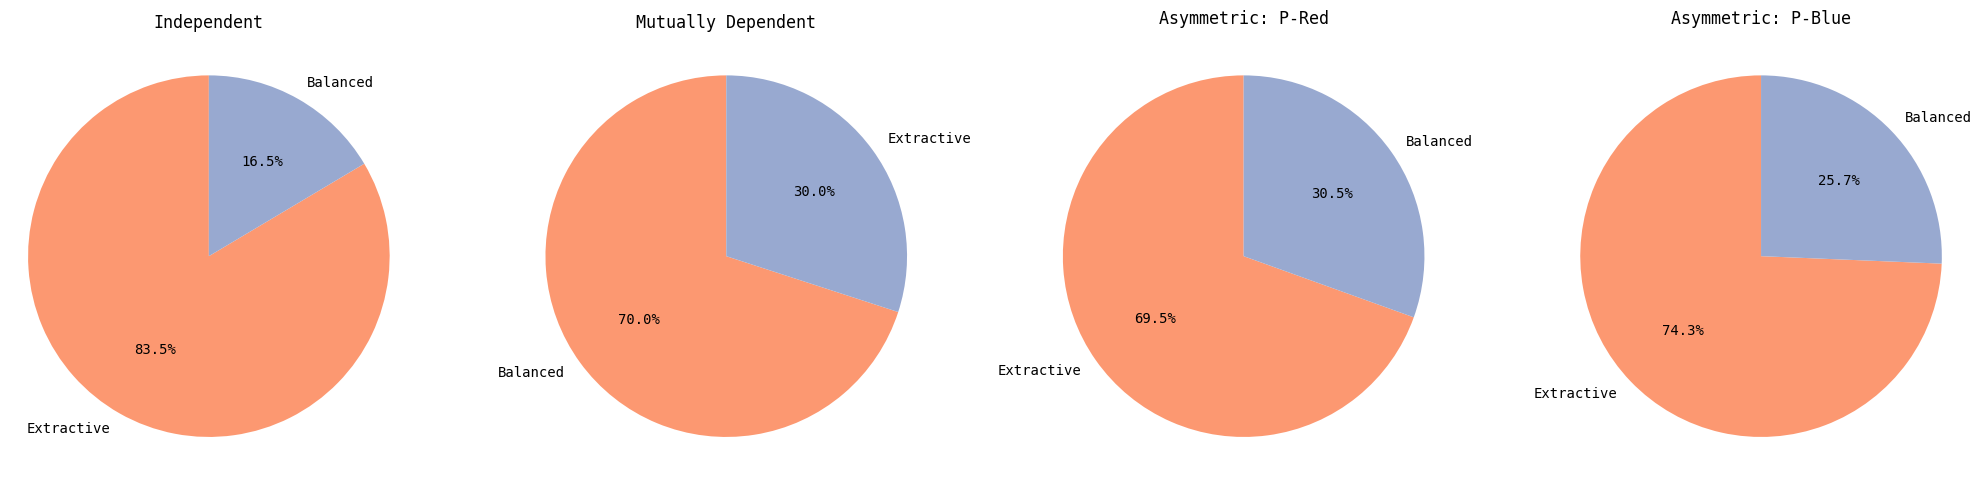

In [21]:
import matplotlib.pyplot as plt

# Define the mapping for environment type labels
environment_type_labels = {
    'independent': 'Independent',
    'mutual': 'Mutually Dependent',
    'needy': 'Asymmetric' # Used for role-split titles
}

# Define colors for reciprocity orientations (consistent with previous plots)
reciprocity_colors = ['#fc9871', '#98a9d0'] # Assuming these are for Extractive, Balanced

# Create a single 1x4 figure for all environment-based reciprocity plots
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 5))
axes = axes.flatten() # Flatten the array of axes for easy iteration

# Plot 1: Independent Environment
env_type = 'independent'
df_filtered_independent = df_negotiations[df_negotiations['environment'] == env_type]
tactic_breakdown_independent = df_filtered_independent['reciprocity_orientation'].value_counts()
if not tactic_breakdown_independent.empty:
    display_label_independent = environment_type_labels.get(env_type, env_type)
    wedges, texts, autotexts = axes[0].pie(tactic_breakdown_independent, labels=tactic_breakdown_independent.index, autopct='%1.1f%%', startangle=90, colors=reciprocity_colors)
    for text in texts: text.set_fontfamily('monospace')
    for autotext in autotexts: autotext.set_fontfamily('monospace')
    axes[0].set_title(display_label_independent, pad=0, fontdict={'family': 'monospace'})
    axes[0].axis('equal')
else:
    axes[0].set_visible(False)
    print(f"No data for environment_type: {env_type}")

# Plot 2: Mutually Dependent Environment
env_type = 'mutual'
df_filtered_mutual = df_negotiations[df_negotiations['environment'] == env_type]
tactic_breakdown_mutual = df_filtered_mutual['reciprocity_orientation'].value_counts()
if not tactic_breakdown_mutual.empty:
    display_label_mutual = environment_type_labels.get(env_type, env_type)
    wedges, texts, autotexts = axes[1].pie(tactic_breakdown_mutual, labels=tactic_breakdown_mutual.index, autopct='%1.1f%%', startangle=90, colors=reciprocity_colors)
    for text in texts: text.set_fontfamily('monospace')
    for autotext in autotexts: autotext.set_fontfamily('monospace')
    axes[1].set_title(display_label_mutual, pad=0, fontdict={'family': 'monospace'})
    axes[1].axis('equal')
else:
    axes[1].set_visible(False)
    print(f"No data for environment_type: {env_type}")

# Filter for the 'needy' (Asymmetric) environment
df_asymmetric = df_negotiations[df_negotiations['environment'] == 'needy'].copy()
# Filter out 'n/a' or NaN values for reciprocity_orientation
df_asymmetric_filtered = df_asymmetric[~df_asymmetric['reciprocity_orientation'].isin(['n/a'])].dropna(subset=['reciprocity_orientation'])

# Plot 3: Asymmetric: P-Red
assistant_df = df_asymmetric_filtered[df_asymmetric_filtered['role'] == 'assistant']
assistant_breakdown = assistant_df['reciprocity_orientation'].value_counts()

if not assistant_breakdown.empty:
    wedges, texts, autotexts = axes[2].pie(assistant_breakdown, labels=assistant_breakdown.index, autopct='%1.1f%%', startangle=90, colors=reciprocity_colors)
    for text in texts: text.set_fontfamily('monospace')
    for autotext in autotexts: autotext.set_fontfamily('monospace')
    axes[2].set_title('Asymmetric: P-Red', fontdict={'family': 'monospace'})
    axes[2].axis('equal')
else:
    axes[2].set_visible(False)
    print("No data for Assistant in Asymmetric environment.")

# Plot 4: Asymmetric: P-Blue
user_df = df_asymmetric_filtered[df_asymmetric_filtered['role'] == 'user']
user_breakdown = user_df['reciprocity_orientation'].value_counts()

if not user_breakdown.empty:
    wedges, texts, autotexts = axes[3].pie(user_breakdown, labels=user_breakdown.index, autopct='%1.1f%%', startangle=90, colors=reciprocity_colors)
    for text in texts: text.set_fontfamily('monospace')
    for autotext in autotexts: autotext.set_fontfamily('monospace')
    axes[3].set_title('Asymmetric: P-Blue', fontdict={'family': 'monospace'})
    axes[3].axis('equal')
else:
    axes[3].set_visible(False)
    print("No data for User in Asymmetric environment.")

plt.tight_layout()
plt.savefig("4.1_negotiation_analysis_environment_level.pdf", bbox_inches='tight')
plt.show()

In [22]:
# Extract p4p meta data for further anlaysis

#p4p metadata
import os
import json
import pandas as pd

# 1. Configuration - Update this to your local repo path
root_dir = "/content/cooperative_ai/public_logs/reduced_config_runs/FOUR_1-FOUR_1/"

def get_environment(path):
    if "Independent" in path: return "independent"
    if "Mutual" in path: return "mutual"
    if "Needy" in path: return "needy"
    return "unknown"

def get_contract_type(path):
    if "contract_for_finishing" in path: return "contract for finishing"
    if "contract_strict" in path: return "strict contract"
    if "contract_none" in path: return "no contract"
    if "contract_tile" in path: return "judge implementation"
    return "other"

def process_metadata_logs(root):
    all_rows = []

    # Valid contract types that contain metadata
    valid_contracts = ["contract for finishing", "strict contract", "judge implementation"]

    for subdir, dirs, files in os.walk(root):
        if "p4ptrue" not in subdir:
            continue

        for file in files:
            if file.startswith("event_log") and file.endswith(".json"):
                file_path = os.path.join(subdir, file)

                # Extract Metadata
                env = get_environment(file_path)
                contract = get_contract_type(file_path)

                # Skip if it's not one of the implementation types that has history
                if contract not in valid_contracts:
                    continue

                grid_id = next((part for part in file_path.split('/') if part.startswith('grid_')), "unknown")

                try:
                    with open(file_path, 'r') as f:
                        data = json.load(f)

                        game_data = data.get('game', {})
                        final_state = game_data.get('final_state', {})
                        metrics = final_state.get('metrics', {})

                        # Construct the row with your base environment columns
                        row = {
                            "environment": env,
                            "grid_id": grid_id,
                            "contract_type": contract
                            }
                            # If metrics exist, merge them into the row to create individual columns
                    if isinstance(metrics, dict):
                              row.update(metrics)
                              all_rows.append(row)

                except Exception as e:
                    print(f"Skipping {file_path} due to error: {e}")

    return pd.DataFrame(all_rows)

# 2. Execute and Display
df_metadata = process_metadata_logs(root_dir)

# Example display: viewing a specific grid's conversation
display(df_metadata.head(20))


,environment,grid_id,contract_type,total_scores,total_accuracy,gini_coefficient,max_possible_score,total_trades_proposed,total_trades_proposed_0,total_trades_proposed_1,...,moves_made_under_strict_contract_0,moves_made_under_strict_contract_1,contract_moves_blocked_by_partner_shortfall_0,contract_moves_blocked_by_partner_shortfall_1,points_for_completion_promised_to_0,points_for_completion_promised_to_1,format_errors_total,format_errors_by_type,format_errors_by_player,format_errors_by_turn
0,needy,grid_110,strict contract,140.0,1.0,0.035714,140.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,{},{},{}
1,needy,grid_110,judge implementation,70.0,0.5,0.500000,140.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,{},{},{}
2,needy,grid_110,contract for finishing,70.0,0.5,0.500000,140.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,{},{},{}
3,needy,grid_107,strict contract,70.0,0.5,0.500000,140.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,{},{},{}
4,needy,grid_107,judge implementation,140.0,1.0,0.107143,140.0,0.0,0.0,0.0,...,4.0,1.0,0.0,0.0,0.0,0.0,0.0,{},{},{}
5,needy,grid_107,contract for finishing,70.0,0.5,0.500000,140.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,20.0,0.0,0.0,{},{},{}
6,needy,grid_141,strict contract,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,needy,grid_141,strict contract,140.0,1.0,0.071429,140.0,0.0,0.0,0.0,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,{},{},{}
8,needy,grid_141,judge implementation,0.0,0.0,0.000000,140.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,{},{},{}
9,needy,grid_141,judge implementation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
# Load p4p metadata for furth anaylysis found here https://github.com/timwyse/cooperative_ai/blob/main/analysis/p4p_metadata.csv

df_meta = pd.read_csv('/content/p4p_metadata.csv')


In [24]:
# Merge with negotiation results
df_merged_negotiations = pd.merge(df_negotiations,
                                  df_meta,
                                  on=['environment', 'grid_id', 'contract_type'],
                                  how='inner')

/tmp/ipykernel_13702/576647840.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  adv_split_summary = df_filtered.groupby(['environment', 'grid_id', 'contract_type']).apply(get_detailed_advantage).reset_index(drop=True)


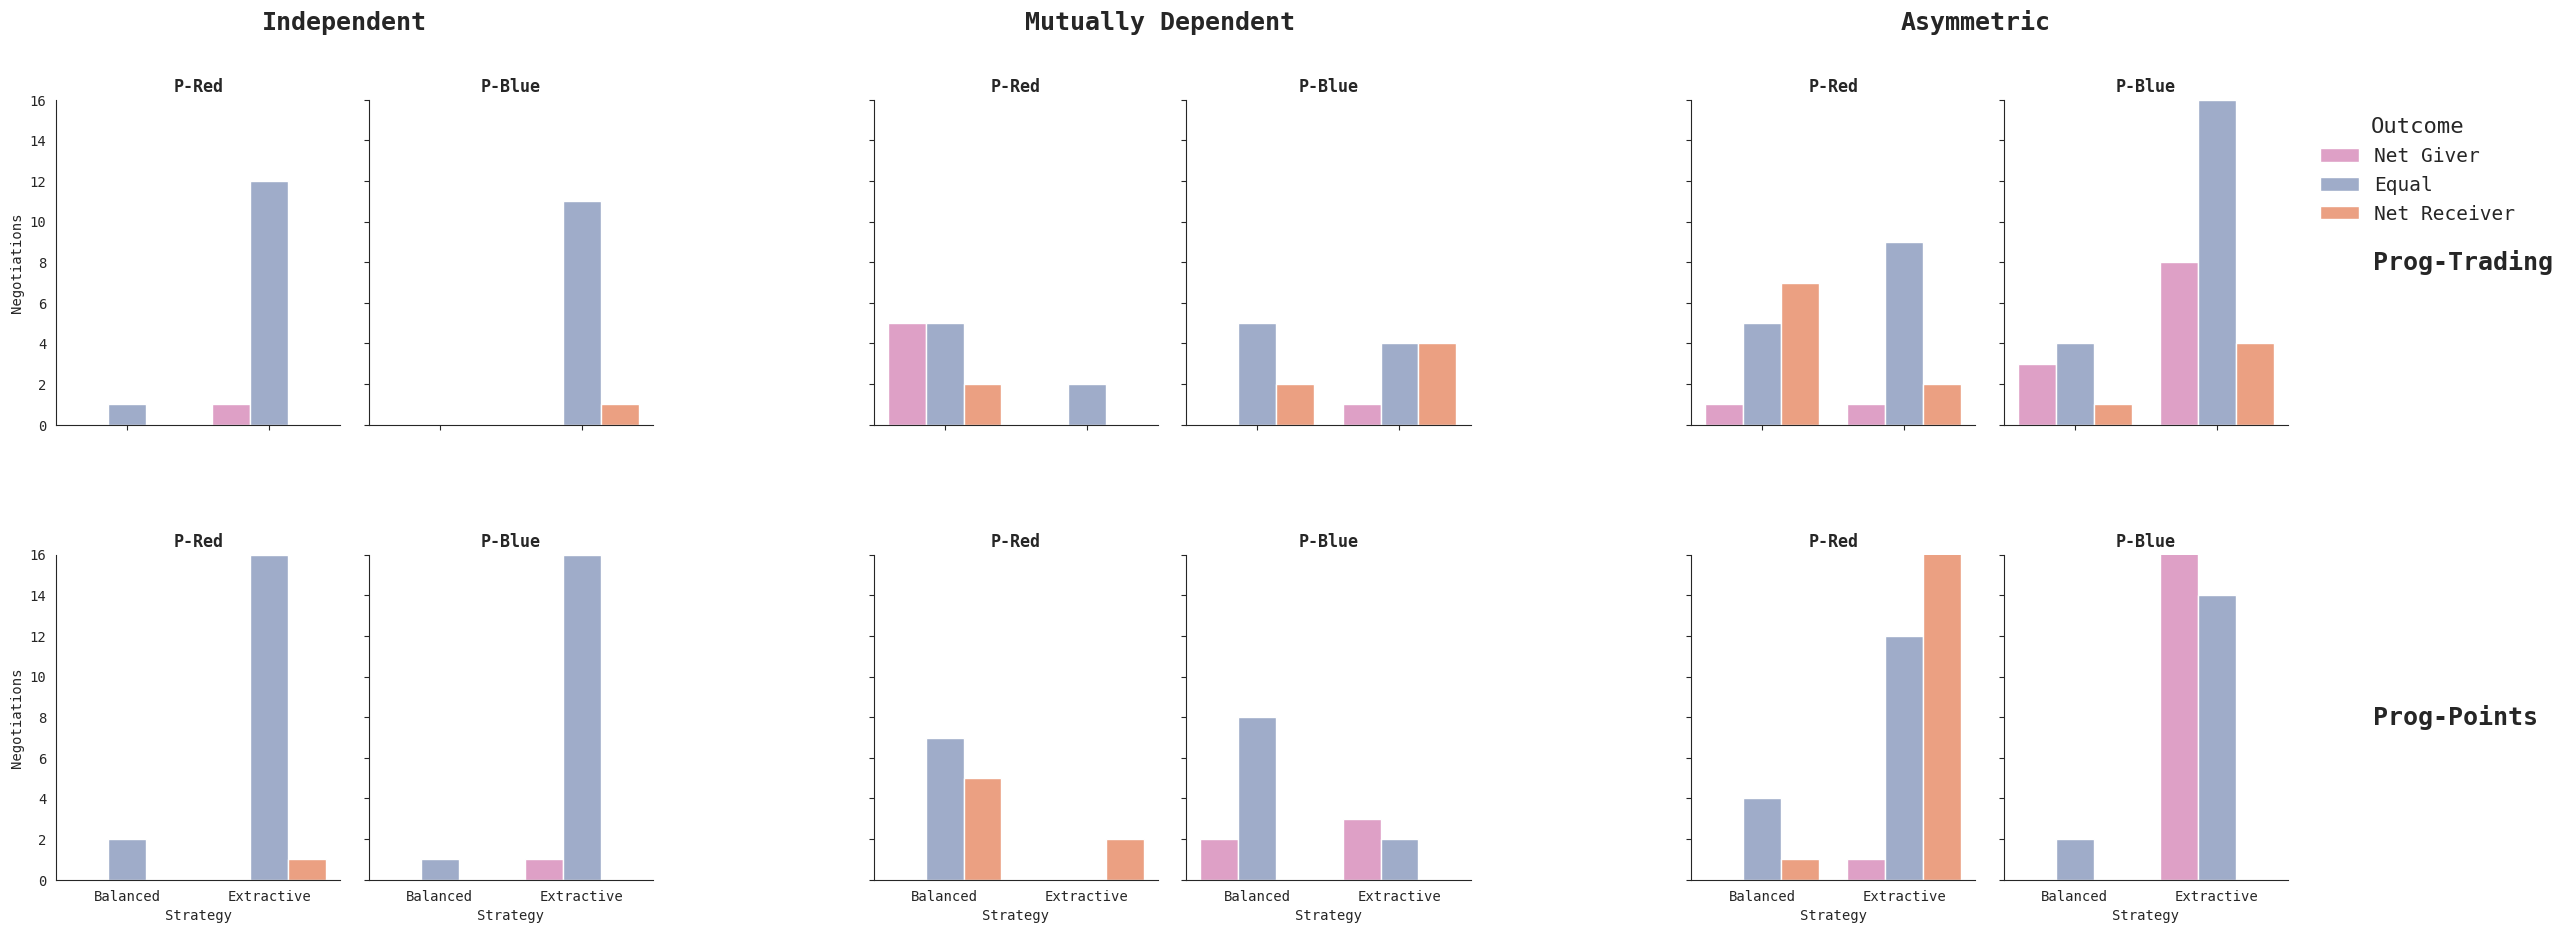

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.ticker as ticker

# 1. Prepare Data
contracts_of_interest = ['strict contract', 'contract for finishing']
df_filtered = df_merged_negotiations[df_merged_negotiations['contract_type'].isin(contracts_of_interest)].copy()

# 2. Player-Level Advantage Analysis
def get_detailed_advantage(group):
    c_type = group['contract_type'].iloc[0]
    if c_type == 'strict contract':
        p0_val, p1_val = group['num_tiles_promised_to_receive_from_contract_0'].iloc[0], group['num_tiles_promised_to_receive_from_contract_1'].iloc[0]
    else:
        p0_val, p1_val = group['points_for_completion_promised_to_0'].iloc[0], group['points_for_completion_promised_to_1'].iloc[0]

    results = []
    for role in ['assistant', 'user']:
        role_data = group[group['role'] == role]
        counts = role_data['reciprocity_orientation'].value_counts()
        ext = counts.get('Extractive', 0)
        bal = counts.get('Balanced', 0)
        dominant = 'Extractive' if ext > bal else ('Balanced' if bal > ext else 'Neutral/Tie')

        if role == 'assistant':
            has_advantage = 'Net Receiver' if p0_val > p1_val else ('Equal' if p0_val == p1_val else 'Net Giver')
        else:
            has_advantage = 'Net Receiver' if p1_val > p0_val else ('Equal' if p1_val == p0_val else 'Net Giver')

        results.append({
            'environment': group['environment'].iloc[0],
            'contract_type': c_type,
            'Outcome': has_advantage,
            'Player': 'P-Red' if role == 'assistant' else 'P-Blue',
            'Dominant_Reciprocity': dominant
        })
    return pd.DataFrame(results)

adv_split_summary = df_filtered.groupby(['environment', 'grid_id', 'contract_type']).apply(get_detailed_advantage).reset_index(drop=True)
contract_map = {'strict contract': 'Prog-Trading', 'contract for finishing': 'Prog-Points'}
adv_split_summary['Display_Contract'] = adv_split_summary['contract_type'].map(contract_map)

# Rename Environments
env_map = {'independent': 'Independent', 'mutual': 'Mutually Dependent', 'needy': 'Asymmetric'}
adv_split_summary['environment'] = adv_split_summary['environment'].map(env_map)

# 3. Visualization
sns.set_style("white")
plot_df = adv_split_summary[adv_split_summary['Dominant_Reciprocity'] != 'Neutral/Tie'].copy()

players = ['P-Red', 'P-Blue']
contracts = ['Prog-Trading', 'Prog-Points']
environments = ['Independent', 'Mutually Dependent', 'Asymmetric']

# Layout: 2 rows (Contracts) x 6 columns (3 Environments * 2 Players)
fig, axes = plt.subplots(nrows=2, ncols=6, figsize=(24, 10))

for r_idx, contract in enumerate(contracts):
    for e_idx, env in enumerate(environments):
        for p_idx, player in enumerate(players):
            c_idx = e_idx * 2 + p_idx
            ax = axes[r_idx, c_idx]

            curr_df = plot_df[(plot_df['environment'] == env) &
                              (plot_df['Display_Contract'] == contract) &
                              (plot_df['Player'] == player)]

            sns.countplot(data=curr_df, x='Dominant_Reciprocity', hue='Outcome',
                          palette={"Net Receiver": "#fc9871", "Equal": "#98a9d0", "Net Giver": "#e995c9"},
                          hue_order=['Net Giver', 'Equal', 'Net Receiver'],
                          ax=ax, order=['Balanced', 'Extractive'])

            # Ensure Axis lines are visible on every graph but hide spines for boxes
            sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
            ax.grid(False)
            ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

            # SET Y AXIS LIMIT TO 16
            ax.set_ylim(0, 16)

            # Strategy label only on bottom row
            ax.set_xlabel("Strategy" if r_idx == 1 else "", fontfamily='monospace')

            # Negotiations label/ticks only on leftmost graph
            if c_idx == 0:
                ax.set_ylabel("Negotiations", fontfamily='monospace')
            else:
                ax.set_ylabel("")
                ax.tick_params(axis='y', which='both', left=True, labelleft=False)

            # Tick values for X-axis only on bottom row
            if r_idx == 0:
                ax.tick_params(axis='x', which='both', bottom=True, labelbottom=False)

            ax.set_title(player, fontsize=12, fontweight='bold', fontfamily='monospace')
            for label in (ax.get_xticklabels() + ax.get_yticklabels()):
                label.set_fontfamily('monospace')

            if r_idx == 0 and c_idx == 5:
                leg = ax.legend(title="Outcome", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, prop={'size': 14})
                plt.setp(leg.get_texts(), fontfamily='monospace')
                plt.setp(leg.get_title(), fontfamily='monospace', size=16)
            else:
                if ax.legend_:
                    ax.legend_.remove()

# Manual offset to create big gaps BETWEEN environments
plt.subplots_adjust(top=0.88, bottom=0.1, left=0.08, right=0.85, hspace=0.4, wspace=0.1)

for e_idx in range(1, 3):
    for r_idx in range(2):
        for p_idx in range(2):
            curr_ax = axes[r_idx, e_idx*2 + p_idx]
            pos = curr_ax.get_position()
            new_pos = [pos.x0 + (e_idx * 0.08), pos.y0, pos.width, pos.height]
            curr_ax.set_position(new_pos)

# Center Environment titles
env_x_positions = [0.20, 0.54, 0.88]
for e_idx, env in enumerate(environments):
    plt.figtext(env_x_positions[e_idx], 0.95, env, ha='center', fontsize=18, fontweight='bold', fontfamily='monospace')

# Horizontal Contract labels (Monospace)
for r_idx, contract in enumerate(contracts):
    axes[r_idx, 5].annotate(contract, xy=(1.3, 0.5), xycoords='axes fraction',
                            fontsize=18, fontweight='bold', ha='left', va='center', fontfamily='monospace')

plt.savefig("4.1_negotiation_analysis_contract_outcomes.pdf", bbox_inches='tight')
plt.show()

/tmp/ipykernel_13702/3601748947.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  first_mover_df = df_md.groupby(['grid_id', 'contract_type']).apply(get_first_mover_advantage).reset_index()


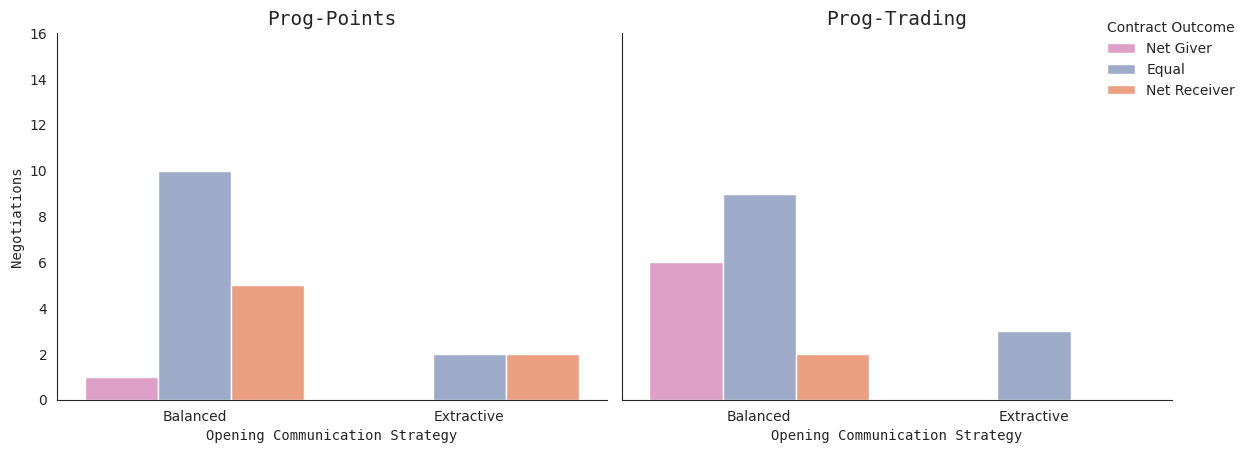

First Mover Success Rates by Strategy and Contract Type:


Outcome_for_First_Mover             Equal  Net Giver  Net Receiver
Display_Contract Opening_Strategy                                 
Prog-Points      Balanced           62.50       6.25         31.25
                 Extractive         50.00       0.00         50.00
Prog-Trading     Balanced           52.94      35.29         11.76
                 Extractive        100.00       0.00          0.00

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Isolate Mutually Dependent games
df_md = df_merged_negotiations[df_merged_negotiations['environment'] == 'mutual'].copy()

# 2. Identify the first negotiator and their strategy for each game
def get_first_mover_advantage(group):
    # Sort by message order to find the very first message
    first_msg = group.sort_values('msg_order').iloc[0]
    first_player = 'P-Red' if first_msg['role'] == 'assistant' else 'P-Blue'
    first_strategy = first_msg['reciprocity_orientation']

    # Determine the outcome for that specific first player
    c_type = group['contract_type'].iloc[0]
    if c_type == 'strict contract':
        p0, p1 = group['num_tiles_promised_to_receive_from_contract_0'].iloc[0], group['num_tiles_promised_to_receive_from_contract_1'].iloc[0]
    else:
        p0, p1 = group['points_for_completion_promised_to_0'].iloc[0], group['points_for_completion_promised_to_1'].iloc[0]

    # Use explicit names: Net Receiver, Equal, Net Giver
    if first_player == 'P-Red':
        outcome = 'Net Receiver' if p0 > p1 else ('Equal' if p0 == p1 else 'Net Giver')
    else:
        outcome = 'Net Receiver' if p1 > p0 else ('Equal' if p1 == p0 else 'Net Giver')

    return pd.Series({
        'First_Mover': first_player,
        'Opening_Strategy': first_strategy,
        'Outcome_for_First_Mover': outcome,
        'Contract_Type': c_type
    })

first_mover_df = df_md.groupby(['grid_id', 'contract_type']).apply(get_first_mover_advantage).reset_index()

# Map contract types for cleaner display
contract_map = {'strict contract': 'Prog-Trading', 'contract for finishing': 'Prog-Points'}
first_mover_df['Display_Contract'] = first_mover_df['Contract_Type'].map(contract_map)

# 3. Visualization
sns.set_style("white")
# Filter out n/a strategies
plot_data = first_mover_df[first_mover_df['Opening_Strategy'].isin(['Extractive', 'Balanced'])]

g = sns.catplot(
    data=plot_data,
    kind="count",
    x="Opening_Strategy",
    hue="Outcome_for_First_Mover",
    col="Display_Contract",
    palette={"Net Receiver": "#fc9871", "Equal": "#98a9d0", "Net Giver": "#e995c9"},
    height=5,
    aspect=1.2,
    hue_order=['Net Giver', 'Equal', 'Net Receiver']
)

g.set_axis_labels("Opening Communication Strategy", "Negotiations", fontfamily='monospace')
g.set_titles("{col_name}", fontfamily='monospace', size=14)

# Move legend up and to the left
g.legend.set_title("Contract Outcome")
sns.move_legend(g, "upper left", bbox_to_anchor=(0.80, 0.90), frameon=False)

for ax in g.axes.flat:
    ax.grid(False)
    # Set Y-axis limit to 16 for consistency
    ax.set_ylim(0, 16)

plt.subplots_adjust(top=0.85)
g.fig.suptitle("", fontfamily='monospace', fontsize=16)
plt.savefig("4.1_negotiation_analysis_md_first_outcomes.pdf", bbox_inches='tight')
plt.show()

# Print Summary Stats
print("First Mover Success Rates by Strategy and Contract Type:")
fm_stats = plot_data.groupby(['Display_Contract', 'Opening_Strategy'])['Outcome_for_First_Mover'].value_counts(normalize=True).unstack().fillna(0) * 100
display(fm_stats.round(2))